# 📐 Part 1: 좌표계 변환 및 DH 파라미터 기초

로봇의 링크(Link)와 관절(Joint)의 위치 관계를 수학적으로 나타내기 위한 **좌표계 변환(Coordinate Transformation)** 기초다. 2D 회전 변환과 DH(Denavit-Hartenberg) 표현법을 실습한다.

## 1. 2D 회전 변환 (2D Rotation)

2D 평면 위의 벡터 $\mathbf{p} = [x, y]^T$를 원점 기준으로 $\theta$만큼 회전시키는 행렬이다.

$$
R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}
$$

$$
\mathbf{p}' = R(\theta) \mathbf{p}
$$

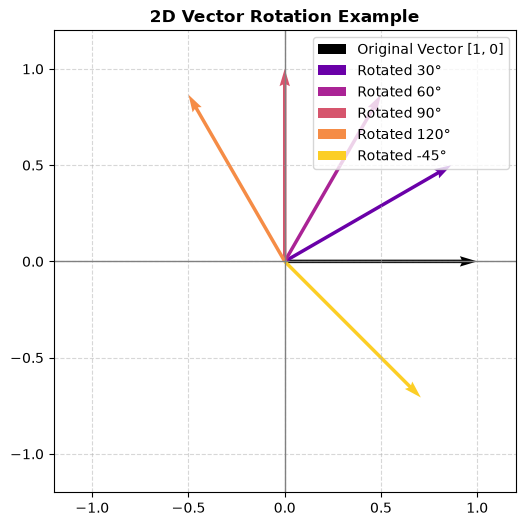

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def rotation_matrix_2d(theta_deg):
    """2차원 회전 행렬 생성 (각도 단위: 도/degree)"""
    theta = np.radians(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s],
        [s,  c]
    ])

# 예제 1: 다양한 각도로 벡터 회전하기
p = np.array([1.0, 0.0]) # x축 방향 길이 1인 벡터
angles = [30, 60, 90, 120, -45]

plt.figure(figsize=(6, 6))
plt.quiver(0, 0, p[0], p[1], angles='xy', scale_units='xy', scale=1, color='black', label='Original Vector [1, 0]')

colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(angles)))
for angle, color in zip(angles, colors):
    R = rotation_matrix_2d(angle)
    p_rot = R @ p
    plt.quiver(0, 0, p_rot[0], p_rot[1], angles='xy', scale_units='xy', scale=1, color=color, 
               label=f'Rotated {angle}°')

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.gca().set_aspect('equal')
plt.title("2D Vector Rotation Example", fontsize=12, fontweight='bold')
plt.legend(loc='upper right')
plt.show()

## 2. 동차 변환 행렬 (Homogeneous Transformation Matrix)

회전(Rotation)과 평행이동(Translation)을 동시에 나타내는 $4 \times 4$ 행렬이다.

$$
T = \begin{bmatrix} R & \mathbf{d} \\ \mathbf{0}^T & 1 \end{bmatrix}
$$

$R$은 $3 \times 3$ 회전 행렬, $\mathbf{d}$는 $3 \times 1$ 평행이동 벡터다.

T_01 (0->1 변환 행렬):
 [[ 0.707 -0.707  0.     0.3  ]
 [ 0.707  0.707  0.     0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]]

T_02 (0->2 최종 변환 행렬):
 [[ 0.259 -0.966  0.     0.441]
 [ 0.966  0.259  0.     0.141]
 [ 0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]]


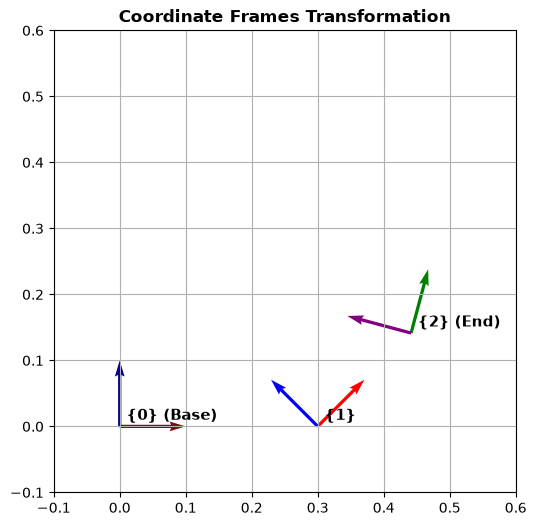

In [3]:
def make_t_matrix_z(theta_deg, tx, ty):
    """z축 기준으로 회전(theta)한 뒤 x방향 tx, y방향 ty 만큼 평행 이동하는 4x4 동차 변환 행렬"""
    theta = np.radians(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s,  0, tx],
        [s,  c,  0, ty],
        [0,  0,  1,  0],
        [0,  0,  0,  1]
    ])

# 예제 2: 여러 좌표계의 합성 변환 (T_02 = T_01 * T_12)
# 좌표계 0에서 1로: 45도 회전, x축 방향으로 0.3 이동
T_01 = make_t_matrix_z(45, 0.3, 0.0)
# 좌표계 1에서 2로: 30도 회전, x축 방향으로 0.2 이동
T_12 = make_t_matrix_z(30, 0.2, 0.0)

# 최종 변환 행렬
T_02 = T_01 @ T_12

print("T_01 (0->1 변환 행렬):\n", np.round(T_01, 3))
print("\nT_02 (0->2 최종 변환 행렬):\n", np.round(T_02, 3))

# 시각화: 원점(0,0)과 변환된 좌표계 축 그리기
fig, ax = plt.subplots(figsize=(6, 6))

def draw_frame(ax, T, label, color_x='red', color_y='blue'):
    """주어진 T 행렬 위치에 좌표축 그리기"""
    origin = T @ np.array([0, 0, 0, 1])
    x_axis = T @ np.array([0.1, 0, 0, 1])
    y_axis = T @ np.array([0, 0.1, 0, 1])
    
    ax.quiver(origin[0], origin[1], x_axis[0]-origin[0], x_axis[1]-origin[1], 
              angles='xy', scale_units='xy', scale=1, color=color_x, width=0.007)
    ax.quiver(origin[0], origin[1], y_axis[0]-origin[0], y_axis[1]-origin[1], 
              angles='xy', scale_units='xy', scale=1, color=color_y, width=0.007)
    ax.text(origin[0]+0.01, origin[1]+0.01, label, fontsize=11, fontweight='bold')

draw_frame(ax, np.eye(4), "{0} (Base)", 'darkred', 'darkblue')
draw_frame(ax, T_01, "{1}")
draw_frame(ax, T_02, "{2} (End)", 'green', 'purple')

ax.set_xlim(-0.1, 0.6)
ax.set_ylim(-0.1, 0.6)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title("Coordinate Frames Transformation", fontsize=12, fontweight='bold')
plt.show()

{2}좌표계가 y축으로 올라간 것처럼 보이지만, {1}좌표계의 관점에서 보면 x축으로 0.2만큼 병진 운동과 30도 회전 운동뿐이다.

## 3. DH(Denavit-Hartenberg) 파라미터 행렬

두 관절 축 사이의 기하학적 관계를 4개의 파라미터로 표준화하여 표현한다.
- $a$: 링크 길이 (Joint 간 거리)
- $\alpha$: 링크 비틀림 각 (Joint 축 간의 각도)
- $d$: 링크 오프셋 (Joint 축 방향 거리)
- $\theta$: 관절 각도 (Joint 기준 회전각)

평면 로봇은 $d=0, \alpha=0$이므로 $a$와 $\theta$로 결정된다.

In [4]:
def dh_matrix(a, d, alpha, theta):
    """DH 파라미터를 입력받아 4x4 동차 변환 행렬을 생성"""
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    
    return np.array([
        [ct, -st * ca,  st * sa, a * ct],
        [st,  ct * ca, -ct * sa, a * st],
        [ 0,       sa,       ca,      d],
        [ 0,        0,        0,      1]
    ])

# 예제 3: DH 행렬을 통한 좌표 변환 확인
# 링크 길이 0.3m, 관절 각도 60도일 때의 변환 행렬
T_dh = dh_matrix(a=0.3, d=0, alpha=0, theta=np.radians(60))
print("DH 변환 행렬 T_dh:\n", np.round(T_dh, 4))

# 원래 로봇 관절의 로컬 좌표계 상 말단부 좌표 [0, 0, 0, 1]를 기준 좌표계로 변환
end_effector_local = np.array([0.0, 0.0, 0.0, 1.0])
end_effector_base = T_dh @ end_effector_local
print(f"\n말단부의 베이스 기준 좌표: {end_effector_base[:2]}")

DH 변환 행렬 T_dh:
 [[ 0.5    -0.866   0.      0.15  ]
 [ 0.866   0.5    -0.      0.2598]
 [ 0.      0.      1.      0.    ]
 [ 0.      0.      0.      1.    ]]

말단부의 베이스 기준 좌표: [0.15       0.25980762]
